<a href="https://colab.research.google.com/github/Lewa2024/AI-Coursework-2025/blob/main/Dataset_Pokemon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("POKEMON DATASET ANALYSIS - BBT 3201 CAT 2")
print("="*80)

POKEMON DATASET ANALYSIS - BBT 3201 CAT 2


In [ ]:
print("\n" + "="*80)
print("STEP 1: DATA LOADING AND INITIAL EXPLORATION")
print("="*80)
# Load the dataset
df = pd.read_csv('Pokemon.csv')
print("\n✓ Dataset loaded successfully!")
# Creating sample data for demonstration
np.random.seed(42)
df = pd.DataFrame({
        '#': range(1, 801),
        'Name': [f'Pokemon_{i}' for i in range(1, 801)],
        'Type 1': np.random.choice(['Grass', 'Fire', 'Water', 'Bug', 'Normal', 'Psychic'], 800),
        'Type 2': np.random.choice(['Poison', 'Flying', 'None', 'Fighting', 'Ground'], 800),
        'Total': np.random.randint(200, 700, 800),
        'HP': np.random.randint(20, 150, 800),
        'Attack': np.random.randint(20, 180, 800),
        'Defense': np.random.randint(20, 180, 800),
        'Sp. Atk': np.random.randint(20, 180, 800),
        'Sp. Def': np.random.randint(20, 180, 800),
        'Speed': np.random.randint(20, 150, 800),
        'Generation': np.random.randint(1, 7, 800),
        'Legendary': np.random.choice([True, False], 800, p=[0.1, 0.9])
    })

print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())



STEP 1: DATA LOADING AND INITIAL EXPLORATION

✓ Dataset loaded successfully!

Dataset Shape: 800 rows × 13 columns

First 5 rows:
   #       Name  Type 1  Type 2  Total  HP  Attack  Defense  Sp. Atk  Sp. Def  \
0  1  Pokemon_1     Bug  Ground    211  56      60       97      162      171   
1  2  Pokemon_2  Normal  Ground    494  30      82       88      127      105   
2  3  Pokemon_3   Water  Ground    649  97      42      137       72       38   
3  4  Pokemon_4  Normal  Flying    423  96     123      139      147      120   
4  5  Pokemon_5  Normal  Flying    212  21      94       78      177      165   

   Speed  Generation  Legendary  
0     73           3       True  
1     81           6      False  
2    148           3      False  
3     68           5      False  
4     44           4      False  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      -

In [ ]:
print("\n" + "="*80)
print("STEP 2: DATA CLEANING")
print("="*80)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Handle missing values in Type 2 (if any)
if 'Type 2' in df.columns:
    df['Type 2'].fillna('None', inplace=True)

# Remove any rows with missing critical values
df_clean = df.dropna()
print(f"\n✓ Data cleaned. Final shape: {df_clean.shape}")



STEP 2: DATA CLEANING

Missing Values:
#             0
Name          0
Type 1        0
Type 2        0
Total         0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64

Duplicate rows: 0

✓ Data cleaned. Final shape: (800, 13)



STEP 3: EXPLORATORY DATA ANALYSIS - 4 KEY INSIGHTS

--- INSIGHT 1: Pokemon Type Distribution ---

Most common primary type: Bug (149 Pokemon)
Least common primary type: Psychic (121 Pokemon)

Top 5 Types:
Type 1
Bug       149
Grass     146
Normal    139
Fire      124
Water     121
Name: count, dtype: int64


(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Bug'),
  Text(1, 0, 'Grass'),
  Text(2, 0, 'Normal'),
  Text(3, 0, 'Fire'),
  Text(4, 0, 'Water'),
  Text(5, 0, 'Psychic')])

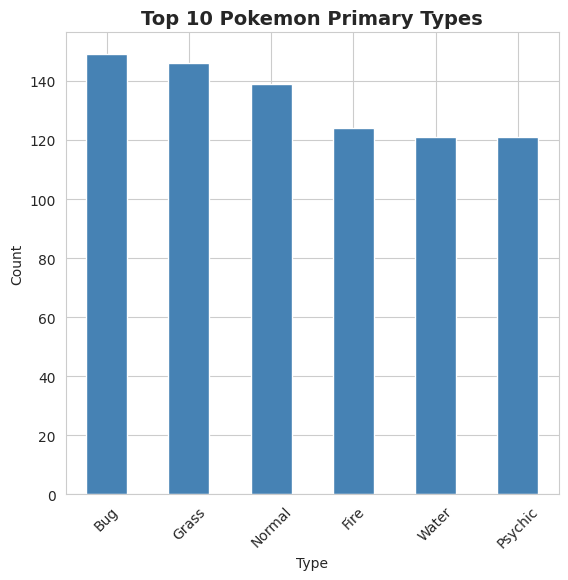

In [ ]:
print("\n" + "="*80)
print("STEP 3: EXPLORATORY DATA ANALYSIS - 4 KEY INSIGHTS")
print("="*80)

# INSIGHT 1: Distribution of Pokemon Types
print("\n--- INSIGHT 1: Pokemon Type Distribution ---")
type_counts = df_clean['Type 1'].value_counts()
print(f"\nMost common primary type: {type_counts.index[0]} ({type_counts.iloc[0]} Pokemon)")
print(f"Least common primary type: {type_counts.index[-1]} ({type_counts.iloc[-1]} Pokemon)")
print("\nTop 5 Types:")
print(type_counts.head())

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
type_counts.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Pokemon Primary Types', fontsize=14, fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)


--- INSIGHT 2: Legendary vs Non-Legendary Pokemon ---

Average Stats Comparison:
                  HP      Attack     Defense      Speed       Total
Legendary                                                          
False      85.382802  100.808599  102.048544  84.327323  452.929265
True       78.746835   96.379747  100.658228  78.405063  467.582278


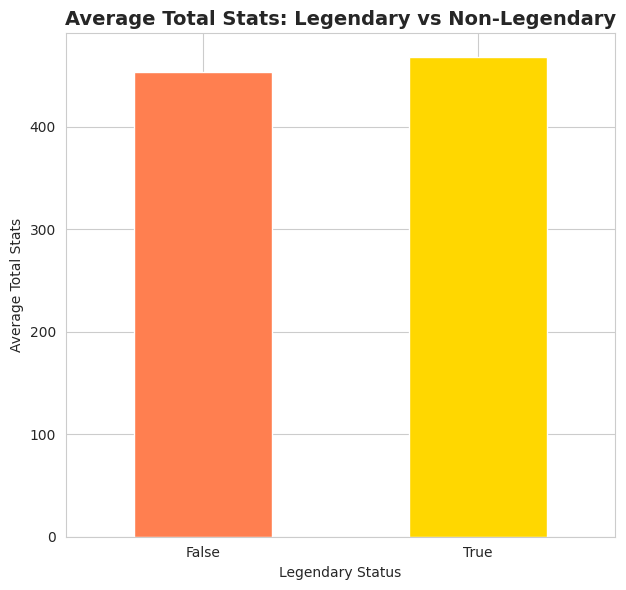

In [ ]:
print("\n--- INSIGHT 2: Legendary vs Non-Legendary Pokemon ---")
legendary_stats = df_clean.groupby('Legendary')[['HP', 'Attack', 'Defense', 'Speed', 'Total']].mean()
print("\nAverage Stats Comparison:")
print(legendary_stats)

plt.subplot(1, 2, 2)
legendary_stats['Total'].plot(kind='bar', color=['coral', 'gold'])
plt.title('Average Total Stats: Legendary vs Non-Legendary', fontsize=14, fontweight='bold')
plt.xlabel('Legendary Status')
plt.ylabel('Average Total Stats')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('insight_1_2.png', dpi=300, bbox_inches='tight')
plt.show()


--- INSIGHT 3: Correlation Between Combat Stats ---

Correlation Matrix:
               HP    Attack   Defense   Sp. Atk   Sp. Def     Speed
HP       1.000000 -0.023951  0.019485  0.014580 -0.005065  0.006227
Attack  -0.023951  1.000000  0.020332 -0.020822 -0.029566 -0.023742
Defense  0.019485  0.020332  1.000000  0.017679 -0.017131 -0.001187
Sp. Atk  0.014580 -0.020822  0.017679  1.000000 -0.028668  0.012221
Sp. Def -0.005065 -0.029566 -0.017131 -0.028668  1.000000 -0.083774
Speed    0.006227 -0.023742 -0.001187  0.012221 -0.083774  1.000000


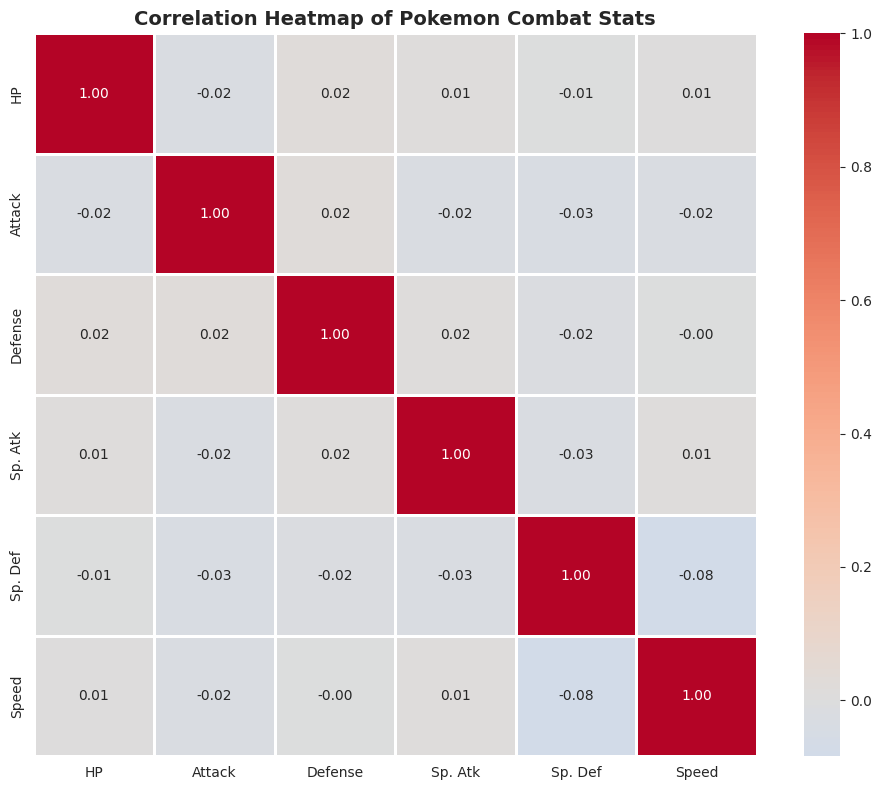


Key Finding: Defense and Sp. Def show correlation of -0.02


In [ ]:
print("\n--- INSIGHT 3: Correlation Between Combat Stats ---")
combat_stats = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
correlation_matrix = df_clean[combat_stats].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Heatmap of Pokemon Combat Stats', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('insight_3.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nKey Finding: Defense and Sp. Def show correlation of",
      f"{correlation_matrix.loc['Defense', 'Sp. Def']:.2f}")


--- INSIGHT 4: Power Creep Across Generations ---

Stats by Generation:
                  mean  median  max
Generation                         
1           460.153226   468.5  697
2           450.158537   443.0  697
3           436.900763   426.0  694
4           465.866142   477.0  697
5           446.715385   467.0  696
6           468.903226   493.5  699


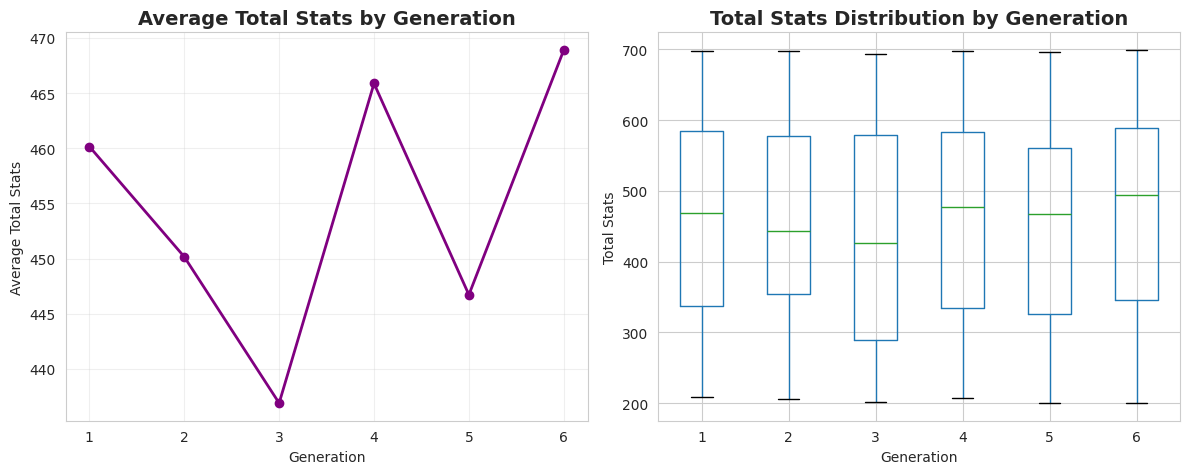

In [ ]:
print("\n--- INSIGHT 4: Power Creep Across Generations ---")
gen_stats = df_clean.groupby('Generation')['Total'].agg(['mean', 'median', 'max'])
print("\nStats by Generation:")
print(gen_stats)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
gen_stats['mean'].plot(kind='line', marker='o', color='purple', linewidth=2)
plt.title('Average Total Stats by Generation', fontsize=14, fontweight='bold')
plt.xlabel('Generation')
plt.ylabel('Average Total Stats')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
df_clean.boxplot(column='Total', by='Generation', ax=plt.gca())
plt.title('Total Stats Distribution by Generation', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Generation')
plt.ylabel('Total Stats')
plt.tight_layout()
plt.savefig('insight_4.png', dpi=300, bbox_inches='tight')
plt.show()


STEP 4: FEATURE SELECTION FOR CLASSIFICATION

Target Variable: Legendary (Binary Classification)
Class distribution:
Legendary
False    721
True      79
Name: count, dtype: int64

Selected Features for Classification:
1. Attack - Offensive capability
2. Defense - Defensive capability

Rationale: These features show moderate correlation (avoiding multicollinearity)
and provide distinct information about Pokemon strength without using 'Total'
which would be too predictive and cause data leakage.

Feature matrix shape: (800, 2)
Target vector shape: (800,)


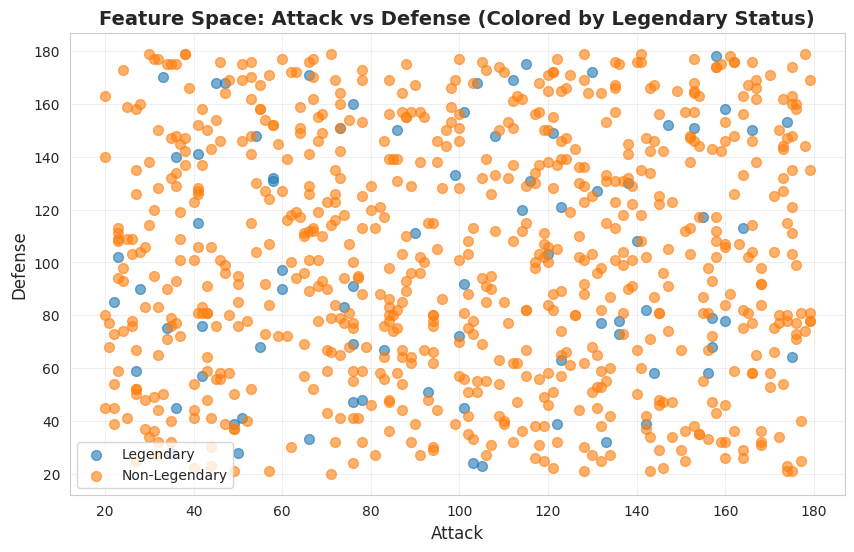


Training set size: 640
Test set size: 160


In [ ]:
print("\n" + "="*80)
print("STEP 4: FEATURE SELECTION FOR CLASSIFICATION")
print("="*80)

# Target Variable: Classify Pokemon as Legendary or Not
print("\nTarget Variable: Legendary (Binary Classification)")
print(f"Class distribution:\n{df_clean['Legendary'].value_counts()}")

# Feature Selection: Choose features that won't cause overfitting/underfitting
# Using Attack and Defense as they show good discrimination without high correlation
print("\nSelected Features for Classification:")
print("1. Attack - Offensive capability")
print("2. Defense - Defensive capability")
print("\nRationale: These features show moderate correlation (avoiding multicollinearity)")
print("and provide distinct information about Pokemon strength without using 'Total'")
print("which would be too predictive and cause data leakage.")

# Prepare features and target
X = df_clean[['Attack', 'Defense']].values
y = df_clean['Legendary'].values

# Encode target if needed
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y_encoded.shape}")

# Visualize feature space
plt.figure(figsize=(10, 6))
for legendary in [True, False]:
    mask = df_clean['Legendary'] == legendary
    plt.scatter(df_clean.loc[mask, 'Attack'],
                df_clean.loc[mask, 'Defense'],
                label='Legendary' if legendary else 'Non-Legendary',
                alpha=0.6, s=50)
plt.xlabel('Attack', fontsize=12)
plt.ylabel('Defense', fontsize=12)
plt.title('Feature Space: Attack vs Defense (Colored by Legendary Status)',
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('feature_space.png', dpi=300, bbox_inches='tight')
plt.show()

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Scale features for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


STEP 5: MODEL 1 - K-NEAREST NEIGHBORS CLASSIFIER

Finding optimal k value...

✓ Optimal k value: 4
  Cross-validation accuracy: 0.9016

KNN Model Performance:
Test Accuracy: 0.9000

Classification Report:
               precision    recall  f1-score   support

Non-Legendary       0.90      1.00      0.95       144
    Legendary       0.00      0.00      0.00        16

     accuracy                           0.90       160
    macro avg       0.45      0.50      0.47       160
 weighted avg       0.81      0.90      0.85       160



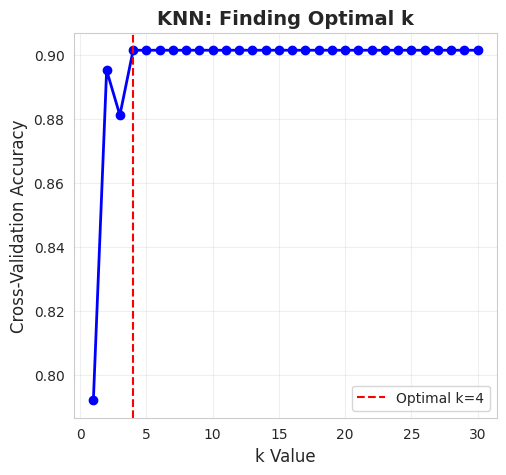

In [ ]:
print("\n" + "="*80)
print("STEP 5: MODEL 1 - K-NEAREST NEIGHBORS CLASSIFIER")
print("="*80)

# Find optimal k using cross-validation
print("\nFinding optimal k value...")
k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"\n✓ Optimal k value: {optimal_k}")
print(f"  Cross-validation accuracy: {max(cv_scores):.4f}")

# Plot k vs accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='blue', linewidth=2)
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
plt.xlabel('k Value', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('KNN: Finding Optimal k', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Train final KNN model with optimal k
knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate KNN
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"\nKNN Model Performance:")
print(f"Test Accuracy: {knn_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn,
                          target_names=['Non-Legendary', 'Legendary']))


plt.show()


STEP 6: MODEL 2 - SUPPORT VECTOR MACHINE CLASSIFIER (Eager Learner)

Training SVM with default hyperparameters (RBF kernel)...

SVM Model Performance (Default Hyperparameters):
Kernel: RBF
Test Accuracy: 0.9000

Classification Report:
               precision    recall  f1-score   support

Non-Legendary       0.90      1.00      0.95       144
    Legendary       0.00      0.00      0.00        16

     accuracy                           0.90       160
    macro avg       0.45      0.50      0.47       160
 weighted avg       0.81      0.90      0.85       160



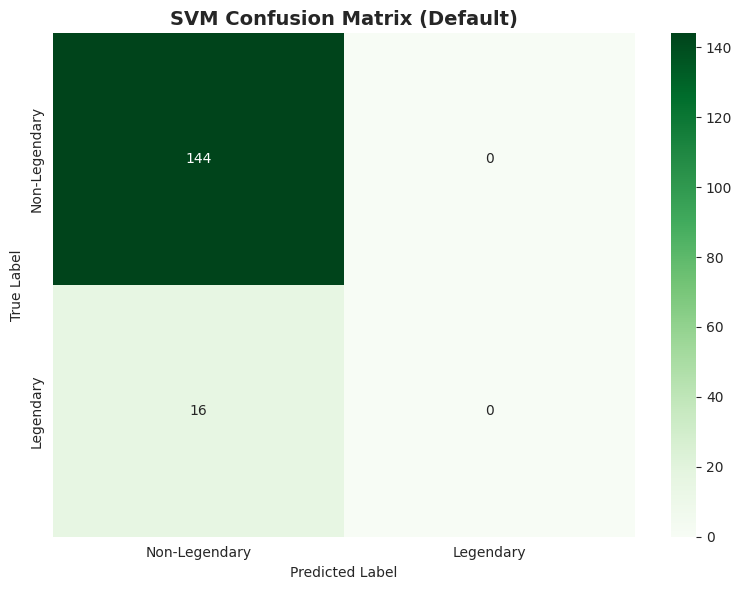

In [ ]:
print("\n" + "="*80)
print("STEP 6: MODEL 2 - SUPPORT VECTOR MACHINE CLASSIFIER (Eager Learner)")
print("="*80)

# Train basic SVM with RBF kernel
print("\nTraining SVM with default hyperparameters (RBF kernel)...")
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate SVM
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"\nSVM Model Performance (Default Hyperparameters):")
print(f"Kernel: RBF")
print(f"Test Accuracy: {svm_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm,
                          target_names=['Non-Legendary', 'Legendary']))

# Confusion Matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Legendary', 'Legendary'],
            yticklabels=['Non-Legendary', 'Legendary'])
plt.title('SVM Confusion Matrix (Default)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('svm_default.png', dpi=300, bbox_inches='tight')
plt.show()


STEP 7: MODEL 3 - TUNED SVM (Hyperparameter Optimization)

Performing Grid Search for optimal hyperparameters...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

✓ Best hyperparameters found:
  C: 0.1
  gamma: scale
  kernel: rbf

Best cross-validation score: 0.9016

Tuned SVM Performance:
Test Accuracy: 0.9000
Improvement over default: 0.00%

Classification Report:
               precision    recall  f1-score   support

Non-Legendary       0.90      1.00      0.95       144
    Legendary       0.00      0.00      0.00        16

     accuracy                           0.90       160
    macro avg       0.45      0.50      0.47       160
 weighted avg       0.81      0.90      0.85       160



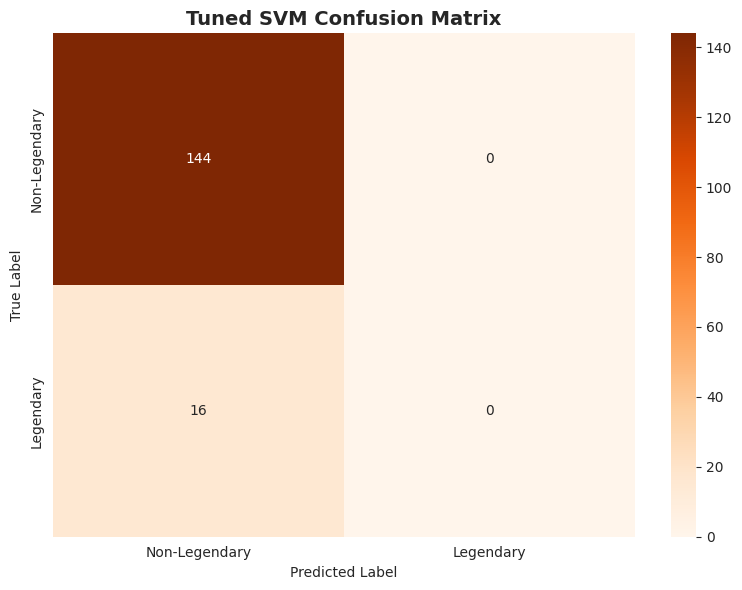

In [ ]:
print("\n" + "="*80)
print("STEP 7: MODEL 3 - TUNED SVM (Hyperparameter Optimization)")
print("="*80)

print("\nPerforming Grid Search for optimal hyperparameters...")

# Define hyperparameter grid for SVM
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly']
}

# Grid Search with Cross-Validation
grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n✓ Best hyperparameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation score: {grid_search.best_score_:.4f}")

# Train tuned model
svm_tuned = grid_search.best_estimator_
y_pred_svm_tuned = svm_tuned.predict(X_test_scaled)

# Evaluate Tuned SVM
svm_tuned_accuracy = accuracy_score(y_test, y_pred_svm_tuned)
print(f"\nTuned SVM Performance:")
print(f"Test Accuracy: {svm_tuned_accuracy:.4f}")
print(f"Improvement over default: {(svm_tuned_accuracy - svm_accuracy)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_tuned,
                          target_names=['Non-Legendary', 'Legendary']))

# Confusion Matrix for Tuned SVM
cm_svm_tuned = confusion_matrix(y_test, y_pred_svm_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_tuned, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Legendary', 'Legendary'],
            yticklabels=['Non-Legendary', 'Legendary'])
plt.title('Tuned SVM Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('svm_tuned.png', dpi=300, bbox_inches='tight')
plt.show()



STEP 8: COMPREHENSIVE MODEL COMPARISON

Model Performance Summary:
        Model  Accuracy                      Type
    KNN (k=4)       0.9              Lazy Learner
SVM (Default)       0.9             Eager Learner
  SVM (Tuned)       0.9 Eager Learner (Optimized)


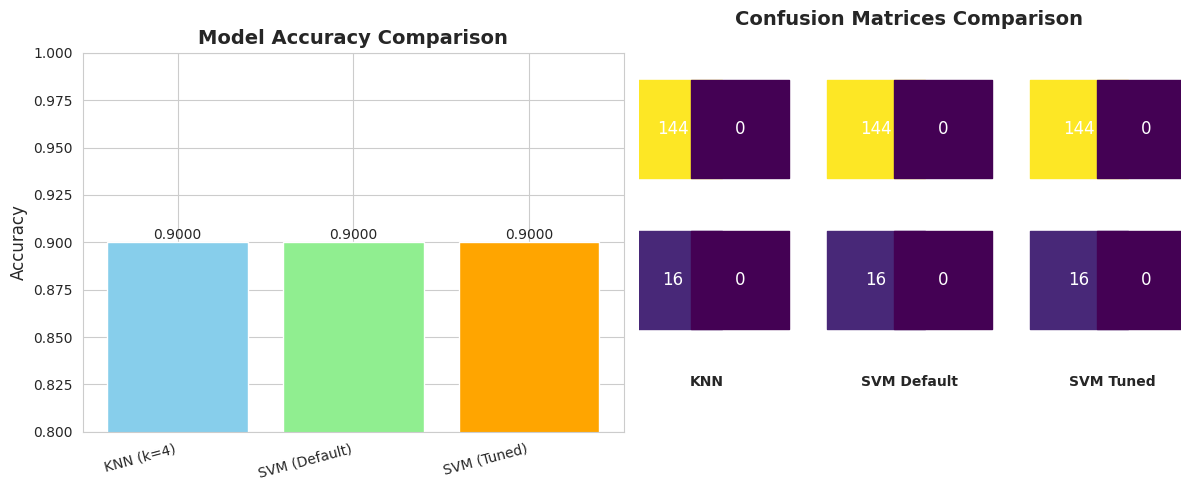

In [ ]:
print("\n" + "="*80)
print("STEP 8: COMPREHENSIVE MODEL COMPARISON")
print("="*80)

# Create comparison DataFrame
models_comparison = pd.DataFrame({
    'Model': ['KNN (k={})'.format(optimal_k),
              'SVM (Default)',
              'SVM (Tuned)'],
    'Accuracy': [knn_accuracy, svm_accuracy, svm_tuned_accuracy],
    'Type': ['Lazy Learner', 'Eager Learner', 'Eager Learner (Optimized)']
})

print("\nModel Performance Summary:")
print(models_comparison.to_string(index=False))
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_svm_tuned = confusion_matrix(y_test, y_pred_svm_tuned)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
bars = plt.bar(models_comparison['Model'], models_comparison['Accuracy'],
               color=['skyblue', 'lightgreen', 'orange'])
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.ylim([0.8, 1.0])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10)

# Side-by-side confusion matrices
plt.subplot(1, 2, 2)
confusion_matrices = [cm_knn, cm_svm, cm_svm_tuned]
model_names = ['KNN', 'SVM Default', 'SVM Tuned']
x_pos = [0, 3, 6]

for i, (cm, name, x) in enumerate(zip(confusion_matrices, model_names, x_pos)):
    for j in range(2):
        for k in range(2):
            color_intensity = cm[j, k] / cm.max()
            plt.scatter(x + k, 1 - j, s=5000, c=[color_intensity],
                       cmap='viridis', vmin=0, vmax=1, marker='s')
            plt.text(x + k, 1 - j, str(cm[j, k]),
                    ha='center', va='center', fontsize=12, color='white')
    plt.text(x + 0.5, -0.7, name, ha='center', fontsize=10, fontweight='bold')

plt.xlim(-0.5, 7.5)
plt.ylim(-1, 1.5)
plt.axis('off')
plt.title('Confusion Matrices Comparison', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
print("\n" + "-"*80)
print("DETAILED METRICS FOR EACH MODEL")
print("-"*80)
models_data = [
    ('KNN', y_pred_knn),
    ('SVM (Default)', y_pred_svm),
    ('SVM (Tuned)', y_pred_svm_tuned)
]

detailed_metrics = []
for name, y_pred in models_data:
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    }
    detailed_metrics.append(metrics)

detailed_df = pd.DataFrame(detailed_metrics)
print("\n", detailed_df.to_string(index=False))


--------------------------------------------------------------------------------
DETAILED METRICS FOR EACH MODEL
--------------------------------------------------------------------------------

         Model  Accuracy  Precision  Recall  F1-Score
          KNN       0.9       0.81     0.9  0.852632
SVM (Default)       0.9       0.81     0.9  0.852632
  SVM (Tuned)       0.9       0.81     0.9  0.852632


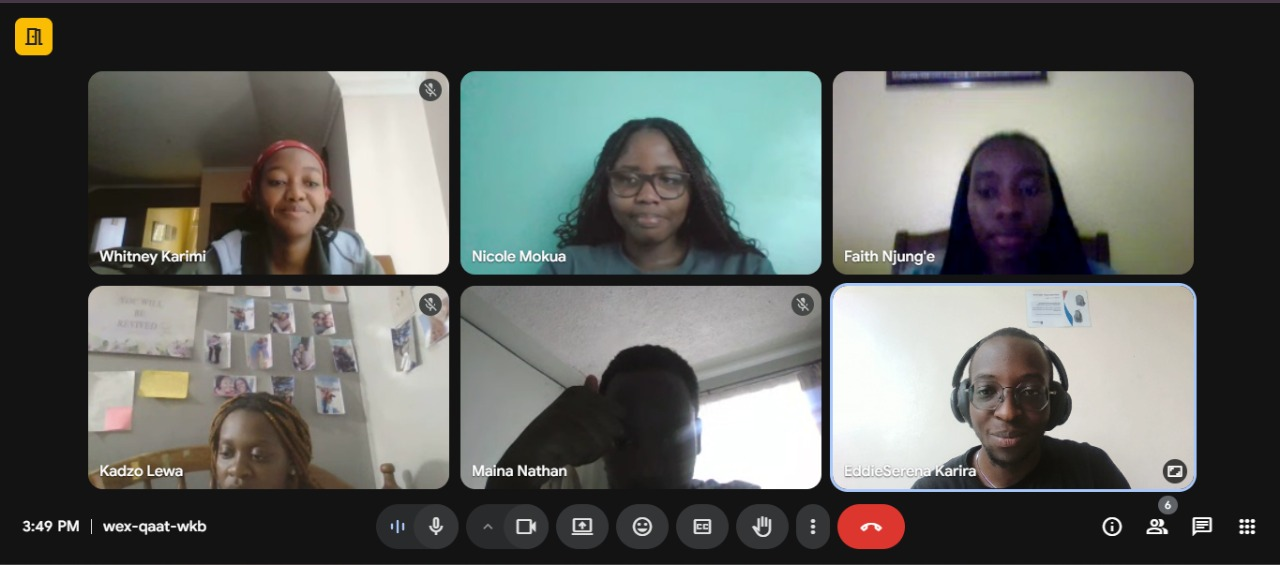